<a href="https://colab.research.google.com/github/Kovalivska/Python/blob/Study/Copy_of_ARIMA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model  import ARIMA
from statsmodels.tsa.seasonal import seasonal_decompose

import matplotlib.pyplot as plt
import seaborn as sns
sns.set(rc={'figure.figsize':(15, 10)})
sns.set(font_scale=2)
sns.set_style("whitegrid")
sns.set_context("talk")

from sklearn.metrics import r2_score, mean_absolute_error
import pandas as pd
import numpy as np

In [4]:
df = pd.read_csv('/content/airline-passengers.csv')
df.head()

,Month,Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


<Axes: >

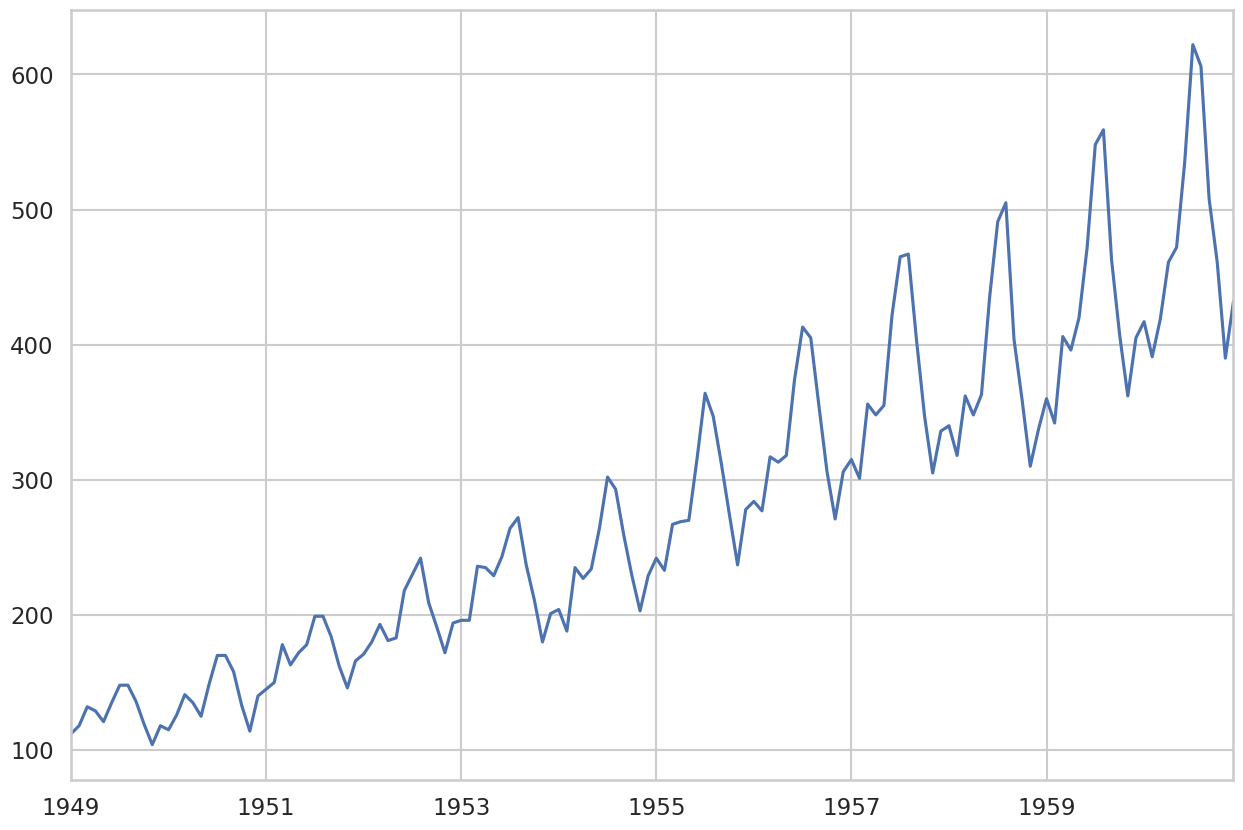

In [5]:
df['Month'] = pd.to_datetime(df['Month'])
df.set_index('Month', inplace=True)
df.index = pd.DatetimeIndex(df.index.values, freq=df.index.inferred_freq)
df['Passengers'].plot()

Seasonal Decomposition
--

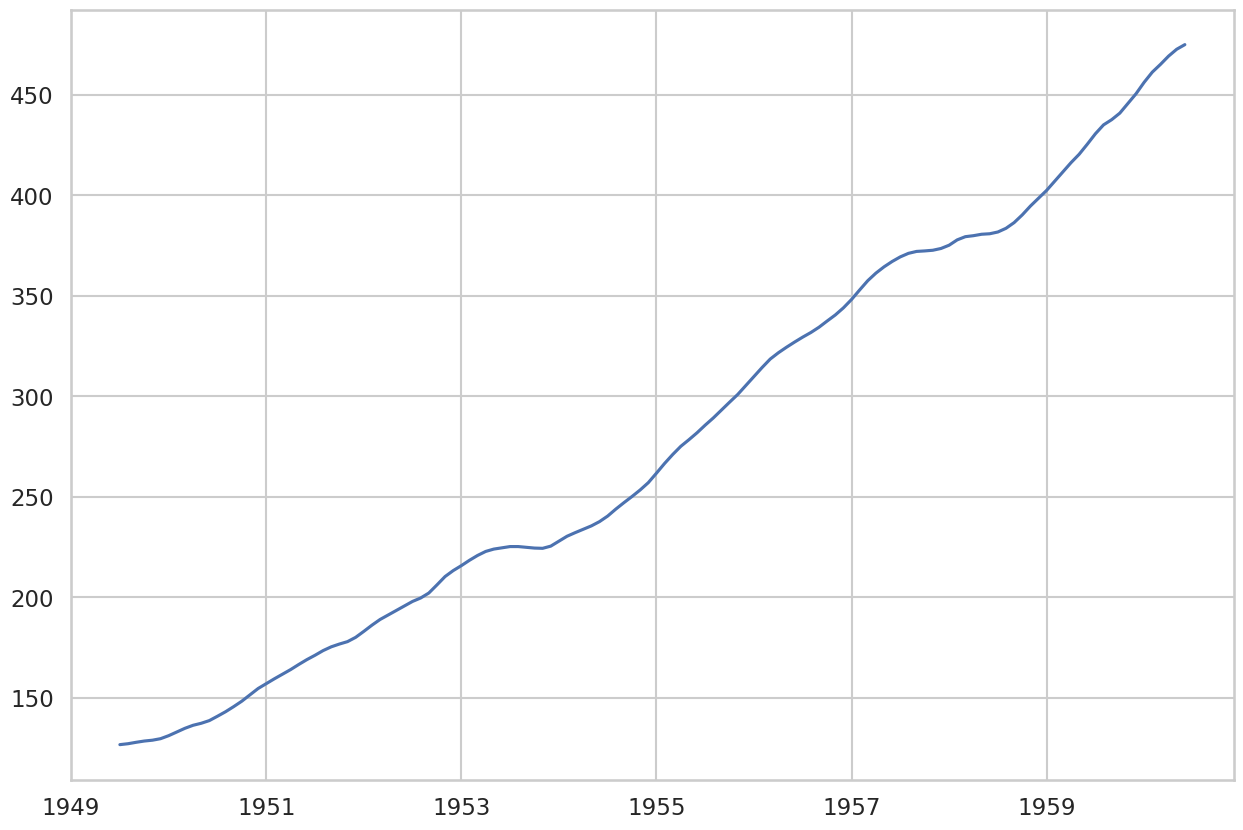

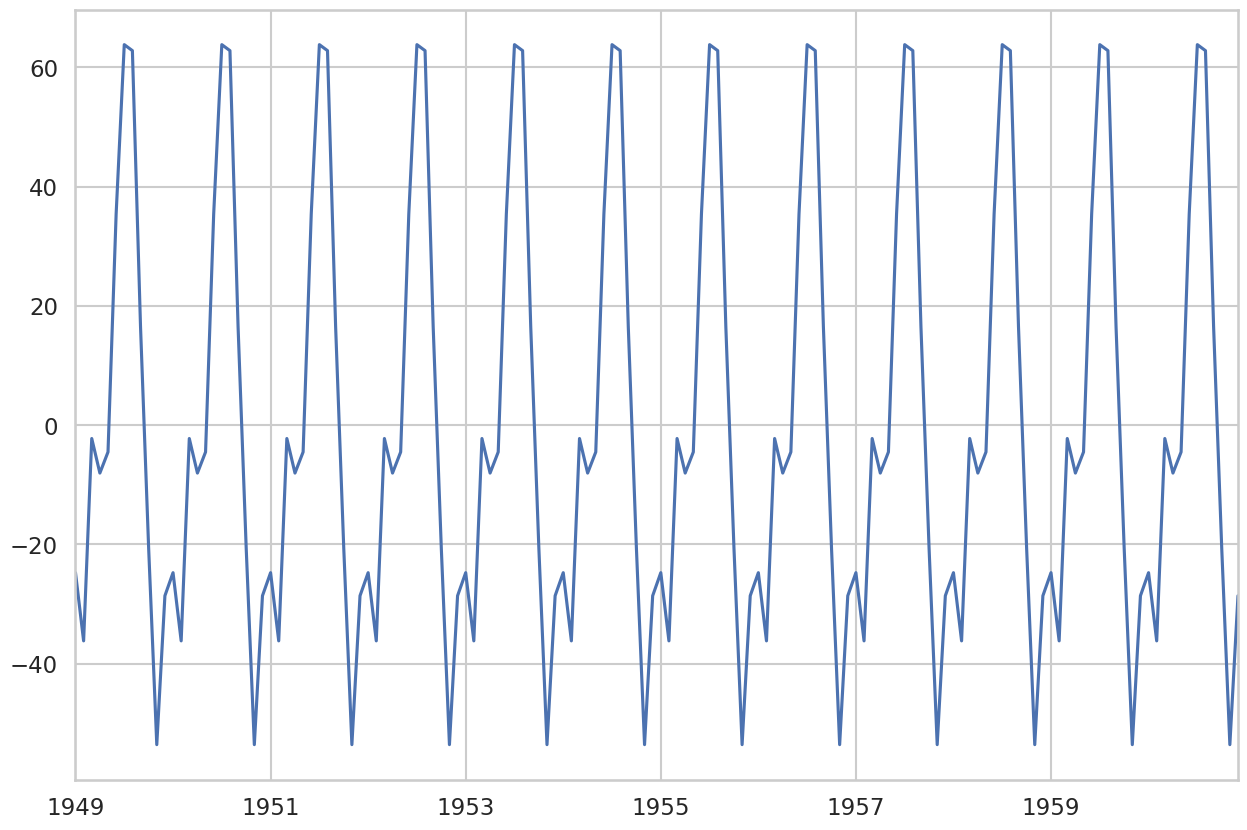

In [6]:
result = seasonal_decompose(df['Passengers'])
result.trend.plot()
plt.show()

result.seasonal.plot()
plt.show()

It is clear that we have a trend in our time series. This means we need to difference it. Let's try using order *d = 1*.

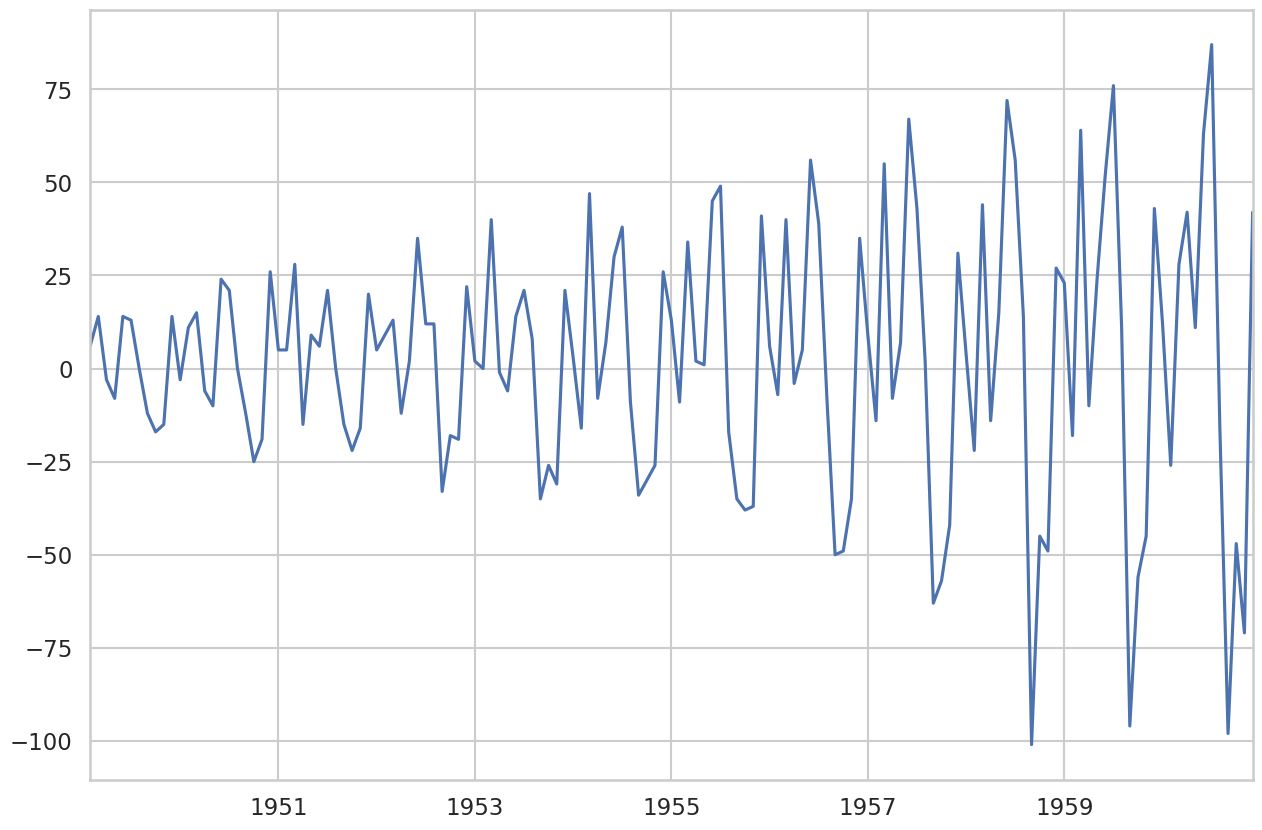

In [7]:
df.Passengers.diff().dropna().plot()
plt.show()

AR: Autoregressive
----

$$\hat y_t = \beta_0 + \beta_1 \cdot \text{lag}(y_t,1), \beta_2 \cdot \text{lag}(y_t, 2), ... , \beta_p \cdot \text{lag}(y_t,p),$$

$$\text{lag}(y_t,i) = y_{t-i}$$

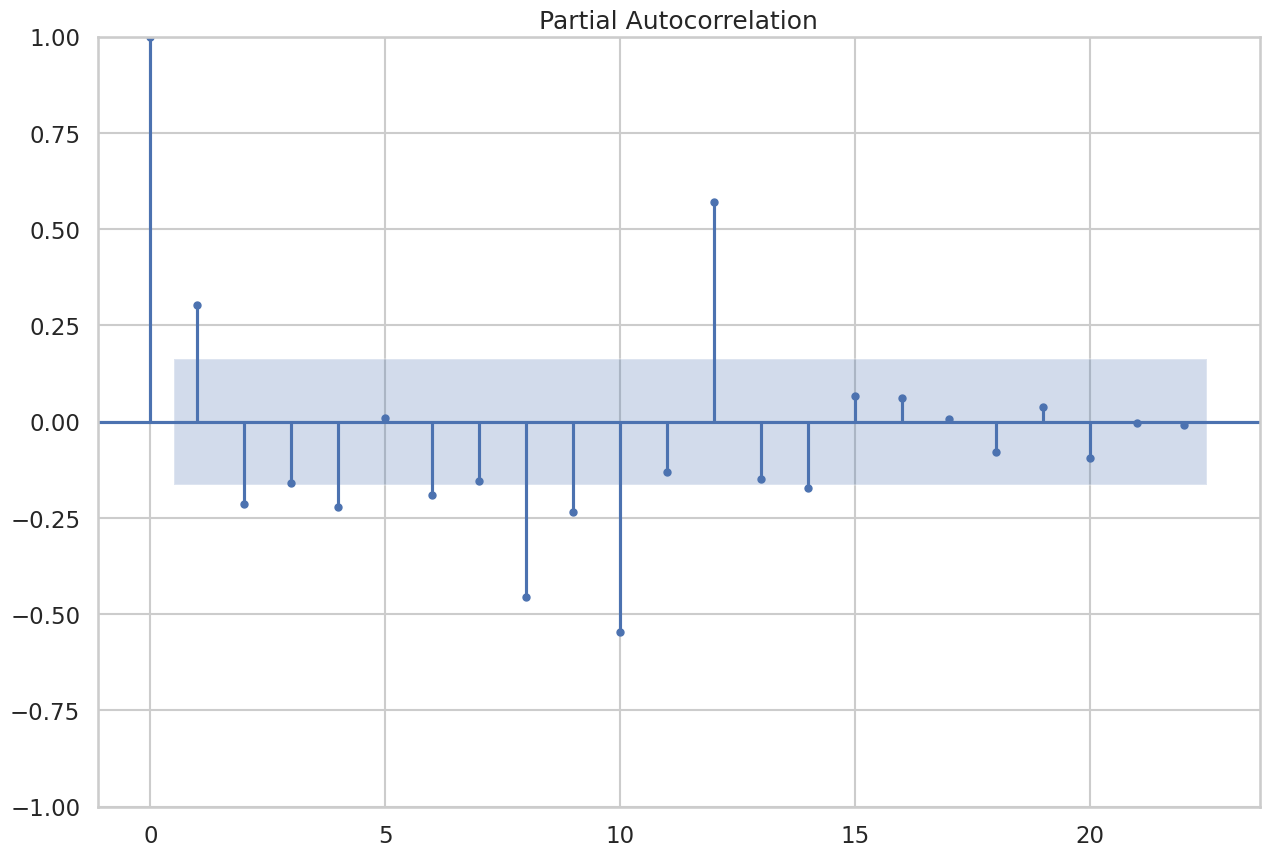

In [8]:
plot_pacf(df['Passengers'].diff().dropna())
plt.show()

MA: Moving Average
---


$$\hat y_t = w_0 + w_1 \varepsilon_{t-1} + \varepsilon_{t-2} + ... + \varepsilon_{t-q},$$

$$\varepsilon_{t-i} = y_t-\hat y_t$$

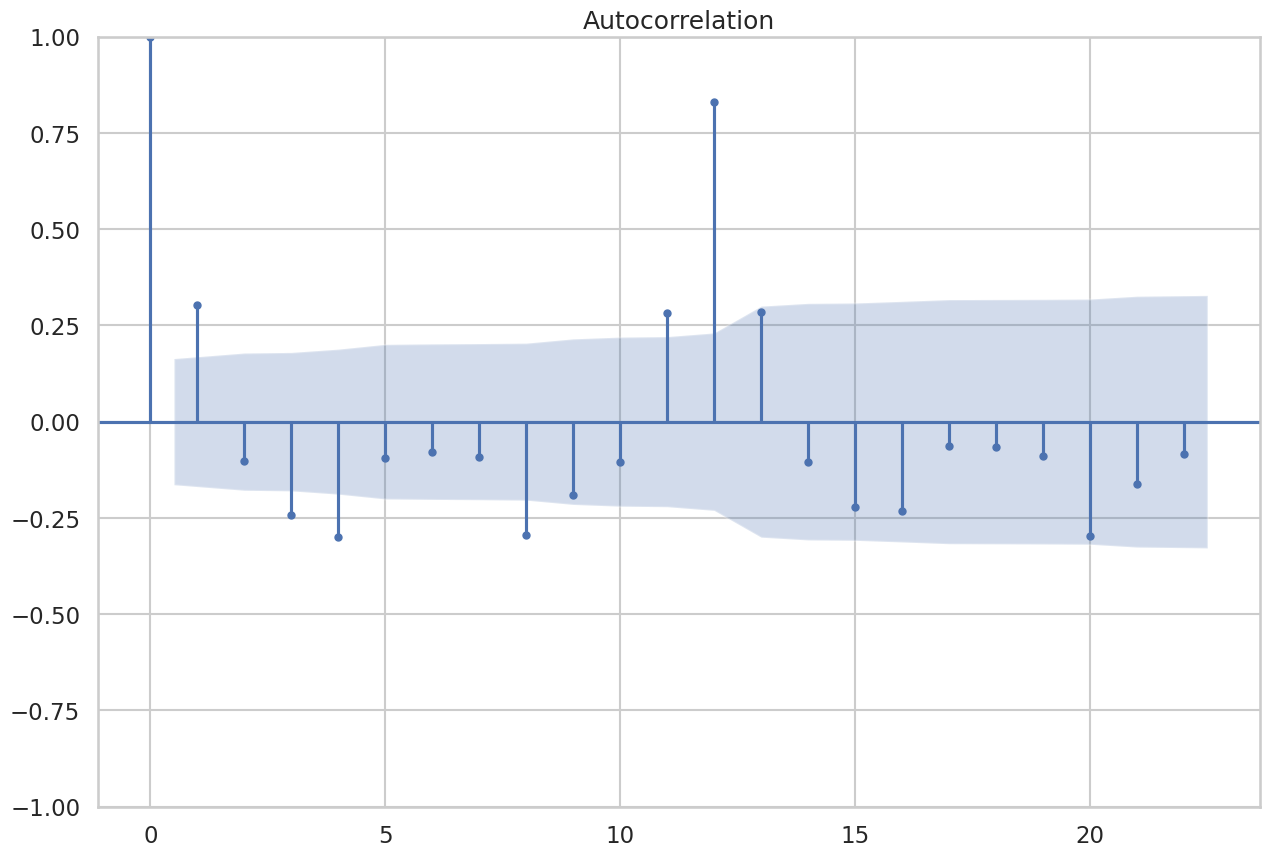

In [9]:
plot_acf(df['Passengers'].diff().dropna())
plt.show()

ARIMA
--

In [10]:
def model_evaluation(model, test_size = 12, exog=None):
    '''
    This function evaluates the model on a given test size
    '''
    train_predictions = model.predict()
    if exog is not None:
        forecast = model.get_forecast(test_size, exog = df[-test_size:][exog])
        test_predictions = forecast.predicted_mean
    else:
        try:
            test_predictions = model.forecast(test_size)
        except:
            test_predictions = model.predict(test_size)
    print(len(test_predictions))
    mae = mean_absolute_error(df[-test_size:]['Passengers'], test_predictions)
    r2 = r2_score(df[-test_size:]['Passengers'], test_predictions)
    print(f'R2 score {np.round(r2,2)}\nMean absolute error {np.round(mae,2)}')
    fig, ax = plt.subplots()
    ax.plot(train_predictions, label = 'Train predictions')
    ax.plot(df['Passengers'], label = 'Input data')
    ax.plot(test_predictions, label = 'Test predictions')
    plt.legend()
    plt.show()

    # add return test predictoins

In [11]:
train, test = df[:-12], df[-12:]

In [12]:
model = ARIMA(endog=train,
              order = (1,1,15))
model_fit = model.fit()
print(model_fit.summary())

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


                               SARIMAX Results                                
Dep. Variable:             Passengers   No. Observations:                  132
Model:                ARIMA(1, 1, 15)   Log Likelihood                -564.762
Date:                Mon, 24 Feb 2025   AIC                           1163.523
Time:                        15:38:17   BIC                           1212.401
Sample:                    01-01-1949   HQIC                          1183.385
                         - 12-01-1959                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.8117      0.260     -3.123      0.002      -1.321      -0.302
ma.L1          0.9830    329.189      0.003      0.998    -644.215     646.181
ma.L2         -0.1011    682.367     -0.000      1.0

/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


12
R2 score 0.37
Mean absolute error 49.62


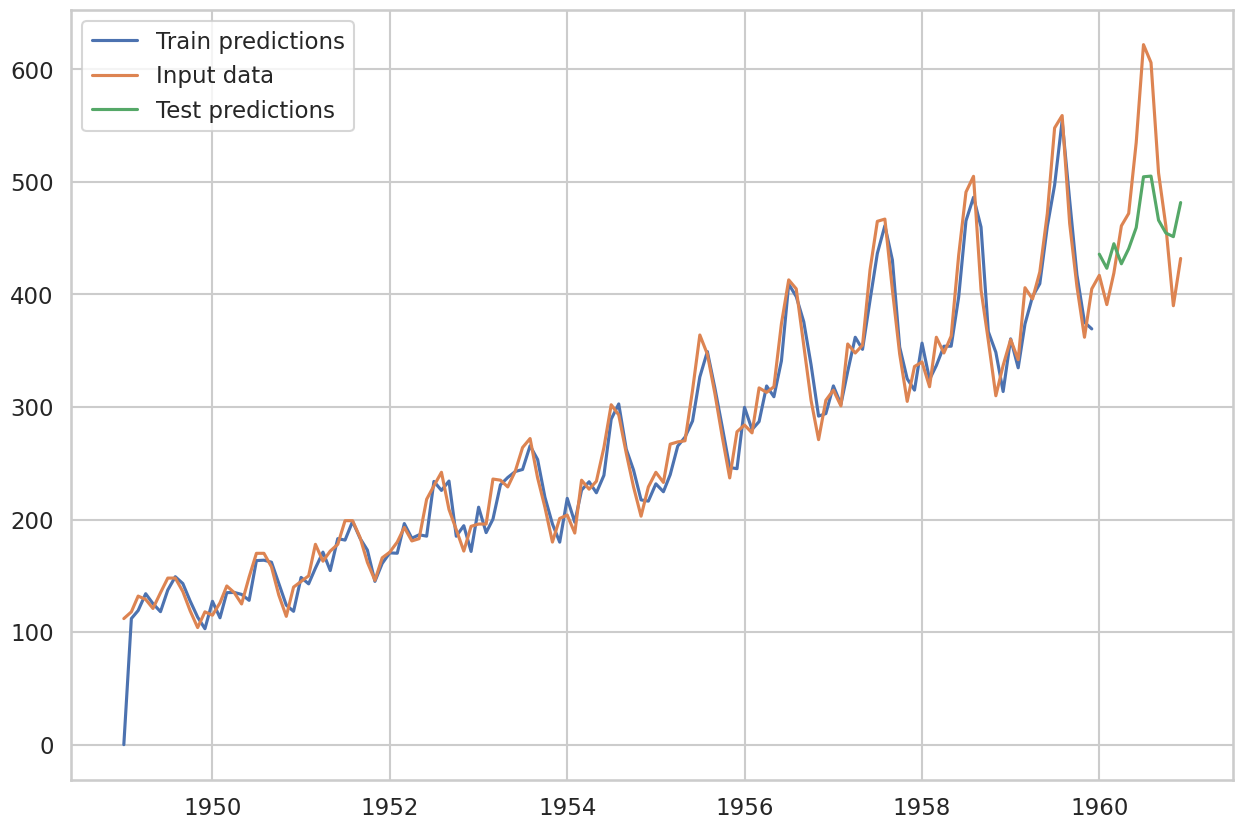

In [13]:
model_evaluation(model_fit)

SARIMA + autoarima
--

In [14]:
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 61.5 MB/s eta 0:00:00


In [15]:
from pmdarima import auto_arima

In [16]:
auto_arima(train,
                   start_p=1,
                   start_q=1,
                   max_p=8,
                   max_q=8,
                   start_P=0,
                   start_Q=0,
                   max_P=8,max_Q=8,
                   m=12,seasonal=True,
                   stepwise=False,
                   suppress_warnings=True,D=1,d=1,error_action='warn',random_state=20,n_fits=30)

#Result - (p,d,q)(P,D,Q)m
# MSE

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11

ARIMA(order=(0, 1, 3), scoring_args={}, seasonal_order=(0, 1, 0, 12),
      suppress_warnings=True, with_intercept=False)

In [17]:
model = auto_arima(train["Passengers"], start_p=1, start_q=1,
                         test='adf',
                         max_p=3, max_q=3,
                         m=12, #12 is the frequncy of the cycle
                         start_P=0,
                         seasonal=True, #set to seasonal
                         d=None,
                         D=1, #order of the seasonal differencing
                         trace=False,
                         error_action='ignore',
                         suppress_warnings=True,
                         stepwise=True)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11

In [18]:
model

ARIMA(order=(1, 1, 0), scoring_args={}, seasonal_order=(0, 1, 0, 12),
      suppress_warnings=True, with_intercept=False)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


12
R2 score 0.9
Mean absolute error 18.53


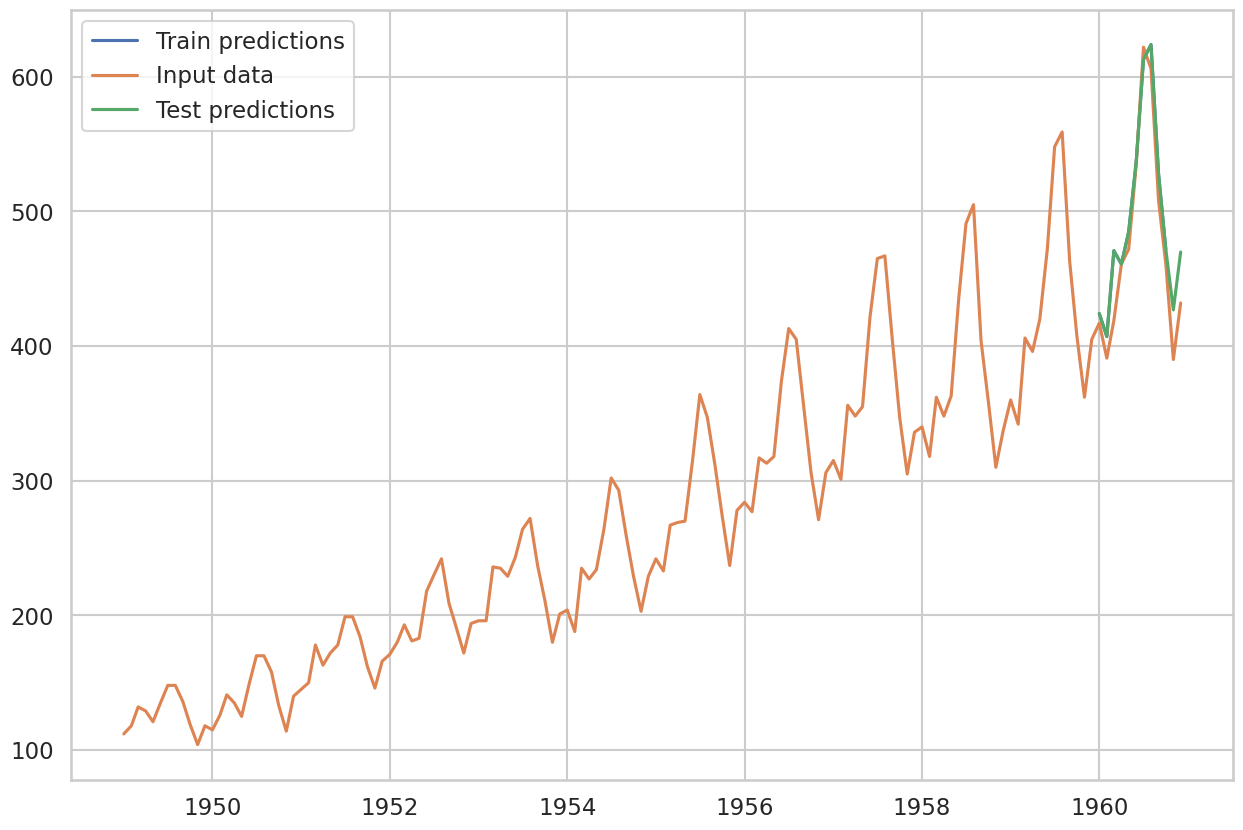

In [19]:
model_evaluation(model)

SARIMAX (Seasonal Auto-Regressive Integrated Moving Average with eXogenous factors)
---

In [20]:
df['month']=df.index.month
train, test = df[:-12], df[-12:]

In [21]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [22]:
order = (1,1,0)
seasonal_order = (0,1,0,12)
sarimax_model = SARIMAX(train['Passengers'], order = order,
                       seasonal_order=seasonal_order,
                        exog = train['month'])


In [23]:
sarimax_model_fit = sarimax_model.fit()

12
R2 score 0.9
Mean absolute error 18.53


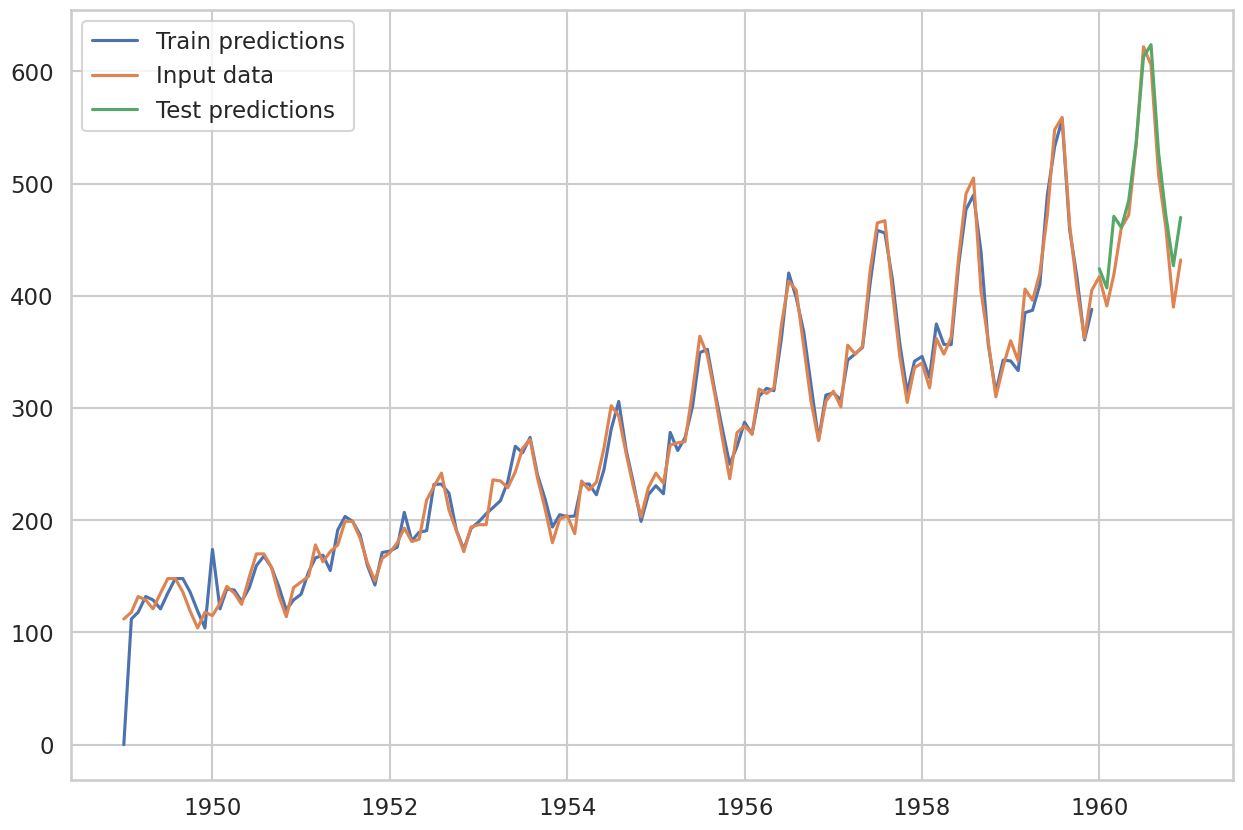

In [24]:
model_evaluation(sarimax_model_fit, exog='month')

In [25]:
help(ARIMA)


Help on class ARIMA in module statsmodels.tsa.arima.model:

class ARIMA(statsmodels.tsa.statespace.sarimax.SARIMAX)
 |  ARIMA(endog, exog=None, order=(0, 0, 0), seasonal_order=(0, 0, 0, 0), trend=None, enforce_stationarity=True, enforce_invertibility=True, concentrate_scale=False, trend_offset=1, dates=None, freq=None, missing='none', validate_specification=True)
 |  
 |  Autoregressive Integrated Moving Average (ARIMA) model, and extensions
 |  
 |  This model is the basic interface for ARIMA-type models, including those
 |  with exogenous regressors and those with seasonal components. The most
 |  general form of the model is SARIMAX(p, d, q)x(P, D, Q, s). It also allows
 |  all specialized cases, including
 |  
 |  - autoregressive models: AR(p)
 |  - moving average models: MA(q)
 |  - mixed autoregressive moving average models: ARMA(p, q)
 |  - integration models: ARIMA(p, d, q)
 |  - seasonal models: SARIMA(P, D, Q, s)
 |  - regression with errors that follow one of the above ARIM